<a href="https://colab.research.google.com/github/sudarshinib2405-sys/Credit_Card_Fraud_Detection_Model/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# STEP 1: Install / setup Kaggle
!pip install kaggle -q

from google.colab import files
files.upload()   # upload kaggle.json here

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


Saving kaggle.json to kaggle.json


In [3]:
# ============================================================
# STEP 2: IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, ttest_ind

from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import joblib

In [4]:
import os
os.listdir()

['.config', 'kaggle.json', 'sample_data']

In [5]:
!rm -rf ~/.kaggle
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
!kaggle datasets download -d kartik2112/fraud-detection

Dataset URL: https://www.kaggle.com/datasets/kartik2112/fraud-detection
License(s): CC0-1.0
100% 202M/202M [00:00<00:00, 219MB/s]



In [7]:
!unzip -o fraud-detection.zip

Archive:  fraud-detection.zip
  inflating: fraudTest.csv           
  inflating: fraudTrain.csv          


In [8]:
!ls

fraud-detection.zip  fraudTest.csv  fraudTrain.csv  kaggle.json  sample_data


In [9]:
import os
print(os.listdir())

['.config', 'fraudTest.csv', 'kaggle.json', 'fraud-detection.zip', 'fraudTrain.csv', 'sample_data']


In [10]:
# ============================================================
# STEP 3: LOAD DATASET
# ============================================================

train_df = pd.read_csv("fraudTrain.csv")
test_df = pd.read_csv("fraudTest.csv")

print(train_df.head())
print(train_df.shape)
print(test_df.shape)
print(train_df.info())

   Unnamed: 0 trans_date_trans_time            cc_num  \
0           0   2019-01-01 00:00:18  2703186189652095   
1           1   2019-01-01 00:00:44      630423337322   
2           2   2019-01-01 00:00:51    38859492057661   
3           3   2019-01-01 00:01:16  3534093764340240   
4           4   2019-01-01 00:03:06   375534208663984   

                             merchant       category     amt      first  \
0          fraud_Rippin, Kub and Mann       misc_net    4.97   Jennifer   
1     fraud_Heller, Gutmann and Zieme    grocery_pos  107.23  Stephanie   
2                fraud_Lind-Buckridge  entertainment  220.11     Edward   
3  fraud_Kutch, Hermiston and Farrell  gas_transport   45.00     Jeremy   
4                 fraud_Keeling-Crist       misc_pos   41.96      Tyler   

      last gender                        street  ...      lat      long  \
0    Banks      F                561 Perry Cove  ...  36.0788  -81.1781   
1     Gill      F  43039 Riley Greens Suite 393  ...  48

In [11]:
# ============================================================
# STEP 4: DATA CLEANING
# ============================================================

train_df = train_df.drop_duplicates()
test_df = test_df.drop_duplicates()

print(train_df.isnull().sum())

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64


In [12]:
# ============================================================
# STEP 5: FEATURE ENGINEERING
# ============================================================

def feature_engineering(df):
    df = df.copy()

    df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
    df["dob"] = pd.to_datetime(df["dob"])

    df["transaction_hour"] = df["trans_date_trans_time"].dt.hour
    df["transaction_day"] = df["trans_date_trans_time"].dt.day
    df["transaction_month"] = df["trans_date_trans_time"].dt.month
    df["transaction_dayofweek"] = df["trans_date_trans_time"].dt.dayofweek

    df["is_night"] = df["transaction_hour"].apply(
        lambda x: 1 if x < 6 or x > 22 else 0
    )

    df["age"] = df["trans_date_trans_time"].dt.year - df["dob"].dt.year

    df["distance"] = np.sqrt(
        (df["lat"] - df["merch_lat"])**2 +
        (df["long"] - df["merch_long"])**2
    )

    df["amount_log"] = np.log1p(df["amt"])

    df["avg_amount_per_customer"] = df.groupby("cc_num")["amt"].transform("mean")

    df["amount_deviation"] = df["amt"] - df["avg_amount_per_customer"]

    df["transaction_count_per_customer"] = df.groupby("cc_num")["amt"].transform("count")

    return df


train_df = feature_engineering(train_df)
test_df = feature_engineering(test_df)

print(train_df.head())

   Unnamed: 0 trans_date_trans_time            cc_num  \
0           0   2019-01-01 00:00:18  2703186189652095   
1           1   2019-01-01 00:00:44      630423337322   
2           2   2019-01-01 00:00:51    38859492057661   
3           3   2019-01-01 00:01:16  3534093764340240   
4           4   2019-01-01 00:03:06   375534208663984   

                             merchant       category     amt      first  \
0          fraud_Rippin, Kub and Mann       misc_net    4.97   Jennifer   
1     fraud_Heller, Gutmann and Zieme    grocery_pos  107.23  Stephanie   
2                fraud_Lind-Buckridge  entertainment  220.11     Edward   
3  fraud_Kutch, Hermiston and Farrell  gas_transport   45.00     Jeremy   
4                 fraud_Keeling-Crist       misc_pos   41.96      Tyler   

      last gender                        street  ... transaction_day  \
0    Banks      F                561 Perry Cove  ...               1   
1     Gill      F  43039 Riley Greens Suite 393  ...          

is_fraud
0    1289169
1       7506
Name: count, dtype: int64
is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64


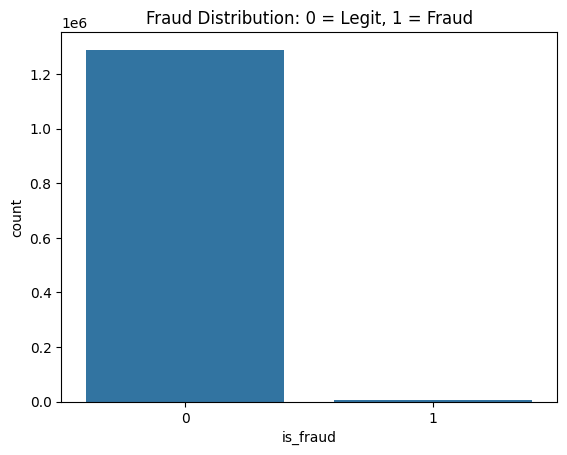

In [13]:
# ============================================================
# STEP 6: EDA - CLASS IMBALANCE
# ============================================================

print(train_df["is_fraud"].value_counts())
print(train_df["is_fraud"].value_counts(normalize=True) * 100)

sns.countplot(x="is_fraud", data=train_df)
plt.title("Fraud Distribution: 0 = Legit, 1 = Fraud")
plt.show()

         Unnamed: 0          trans_date_trans_time        cc_num  \
count  1.296675e+06                        1296675  1.296675e+06   
mean   6.483370e+05  2019-10-03 12:47:28.070214144  4.171920e+17   
min    0.000000e+00            2019-01-01 00:00:18  6.041621e+10   
25%    3.241685e+05     2019-06-03 19:12:22.500000  1.800429e+14   
50%    6.483370e+05            2019-10-03 07:35:47  3.521417e+15   
75%    9.725055e+05     2020-01-28 15:02:55.500000  4.642255e+15   
max    1.296674e+06            2020-06-21 12:13:37  4.992346e+18   
std    3.743180e+05                            NaN  1.308806e+18   

                amt           zip           lat          long      city_pop  \
count  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06   
mean   7.035104e+01  4.880067e+04  3.853762e+01 -9.022634e+01  8.882444e+04   
min    1.000000e+00  1.257000e+03  2.002710e+01 -1.656723e+02  2.300000e+01   
25%    9.650000e+00  2.623700e+04  3.462050e+01 -9.679800e+01  7.430000

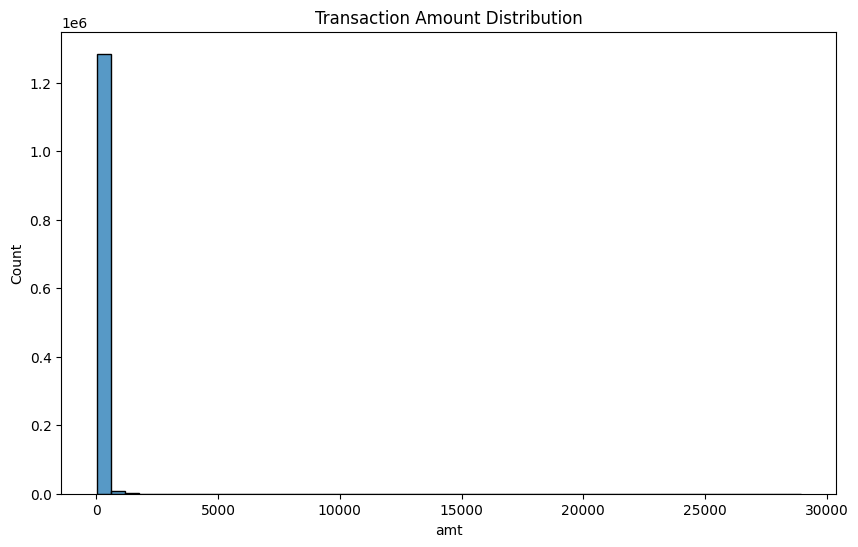

In [14]:
# ============================================================
# STEP 7: EDA - NUMERICAL SUMMARY
# ============================================================

print(train_df.describe())

plt.figure(figsize=(10, 6))
sns.histplot(train_df["amt"], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

In [15]:
# ============================================================
# STEP 8: STATISTICAL TESTS
# ============================================================

# Chi-square test: categorical feature vs fraud target

for col in ["category", "gender", "state"]:
    table = pd.crosstab(train_df[col], train_df["is_fraud"])
    chi2, p, dof, expected = chi2_contingency(table)
    print(f"\nChi-square test for {col} vs is_fraud")
    print("p-value:", p)


# T-test: numerical feature vs fraud target

for col in ["amt", "amount_log", "transaction_hour", "age", "distance", "amount_deviation"]:
    group_0 = train_df[train_df["is_fraud"] == 0][col]
    group_1 = train_df[train_df["is_fraud"] == 1][col]
    t_stat, p_value = ttest_ind(group_0, group_1)
    print(f"\nT-test for {col} vs is_fraud")
    print("p-value:", p_value)


Chi-square test for category vs is_fraud
p-value: 0.0

Chi-square test for gender vs is_fraud
p-value: 3.627211385830374e-18

Chi-square test for state vs is_fraud
p-value: 0.0

T-test for amt vs is_fraud
p-value: 0.0

T-test for amount_log vs is_fraud
p-value: 0.0

T-test for transaction_hour vs is_fraud
p-value: 1.2070269031693197e-55

T-test for age vs is_fraud
p-value: 1.1922562185026235e-45

T-test for distance vs is_fraud
p-value: 0.6210261284232232

T-test for amount_deviation vs is_fraud
p-value: 0.0


In [16]:
# ============================================================
# STEP 9: DROP UNNECESSARY COLUMNS
# ============================================================

drop_cols = [
    "Unnamed: 0",
    "trans_date_trans_time",
    "cc_num",
    "first",
    "last",
    "street",
    "city",
    "zip",
    "dob",
    "trans_num",
    "unix_time",
    "merchant",
    "job"
]

train_df = train_df.drop(columns=drop_cols, errors="ignore")
test_df = test_df.drop(columns=drop_cols, errors="ignore")

print(train_df.head())
print(train_df.columns)

        category     amt gender state      lat      long  city_pop  merch_lat  \
0       misc_net    4.97      F    NC  36.0788  -81.1781      3495  36.011293   
1    grocery_pos  107.23      F    WA  48.8878 -118.2105       149  49.159047   
2  entertainment  220.11      M    ID  42.1808 -112.2620      4154  43.150704   
3  gas_transport   45.00      M    MT  46.2306 -112.1138      1939  47.034331   
4       misc_pos   41.96      M    VA  38.4207  -79.4629        99  38.674999   

   merch_long  is_fraud  ...  transaction_day  transaction_month  \
0  -82.048315         0  ...                1                  1   
1 -118.186462         0  ...                1                  1   
2 -112.154481         0  ...                1                  1   
3 -112.561071         0  ...                1                  1   
4  -78.632459         0  ...                1                  1   

   transaction_dayofweek  is_night  age  distance  amount_log  \
0                      1         1   31

In [17]:
# ============================================================
# STEP 10: MISSING VALUE HANDLING
# ============================================================

num_cols_train = train_df.select_dtypes(exclude=["object"]).columns
cat_cols_train = train_df.select_dtypes(include=["object"]).columns

train_df[num_cols_train] = train_df[num_cols_train].fillna(train_df[num_cols_train].median())

for col in cat_cols_train:
    train_df[col] = train_df[col].fillna(train_df[col].mode()[0])


num_cols_test = test_df.select_dtypes(exclude=["object"]).columns
cat_cols_test = test_df.select_dtypes(include=["object"]).columns

test_df[num_cols_test] = test_df[num_cols_test].fillna(test_df[num_cols_test].median())

for col in cat_cols_test:
    test_df[col] = test_df[col].fillna(test_df[col].mode()[0])

print(train_df.isnull().sum().sum())
print(test_df.isnull().sum().sum())

0
0


In [18]:
# ============================================================
# STEP 11: SPLIT FEATURES AND TARGET
# ============================================================

X_train = train_df.drop("is_fraud", axis=1)
y_train = train_df["is_fraud"]

X_test = test_df.drop("is_fraud", axis=1)
y_test = test_df["is_fraud"]

categorical_cols = X_train.select_dtypes(include=["object"]).columns
numerical_cols = X_train.select_dtypes(exclude=["object"]).columns

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: Index(['category', 'gender', 'state'], dtype='object')
Numerical columns: Index(['amt', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long',
       'transaction_hour', 'transaction_day', 'transaction_month',
       'transaction_dayofweek', 'is_night', 'age', 'distance', 'amount_log',
       'avg_amount_per_customer', 'amount_deviation',
       'transaction_count_per_customer'],
      dtype='object')


In [19]:
# ============================================================
# STEP 12: PREPROCESSING PIPELINE
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)


MODEL: Logistic Regression
Accuracy: 0.8784295660216764
Precision: 0.027300844028211355
Recall: 0.8806526806526807
F1-score: 0.05295989458485779
ROC-AUC: 0.9521707261825114
              precision    recall  f1-score   support

           0       1.00      0.88      0.94    553574
           1       0.03      0.88      0.05      2145

    accuracy                           0.88    555719
   macro avg       0.51      0.88      0.49    555719
weighted avg       1.00      0.88      0.93    555719



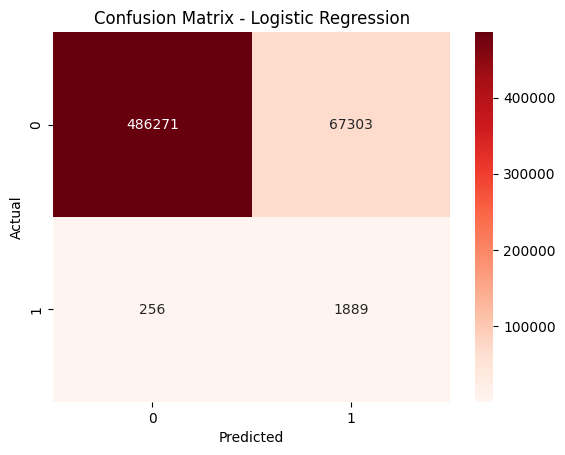


MODEL: Random Forest
Accuracy: 0.9928812943232102
Precision: 0.3420547706261992
Recall: 0.9142191142191142
F1-score: 0.49784209190149786
ROC-AUC: 0.9943222756859236
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    553574
           1       0.34      0.91      0.50      2145

    accuracy                           0.99    555719
   macro avg       0.67      0.95      0.75    555719
weighted avg       1.00      0.99      0.99    555719



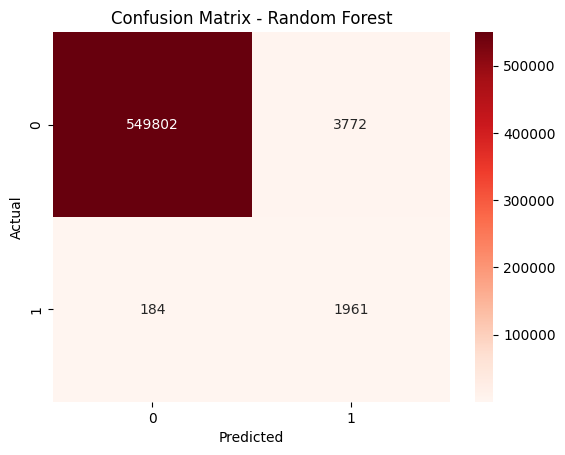

In [20]:
# ============================================================
# STEP 13: BASELINE MODEL TRAINING
# ============================================================

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )
}

results = {}

for name, model in models.items():

    print("\n" + "=" * 60)
    print("MODEL:", name)

    pipe = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

    print("Accuracy:", results[name]["Accuracy"])
    print("Precision:", results[name]["Precision"])
    print("Recall:", results[name]["Recall"])
    print("F1-score:", results[name]["F1-score"])
    print("ROC-AUC:", results[name]["ROC-AUC"])

    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Reds")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

                     Accuracy  Precision    Recall  F1-score   ROC-AUC
Logistic Regression  0.878430   0.027301  0.880653  0.052960  0.952171
Random Forest        0.992881   0.342055  0.914219  0.497842  0.994322


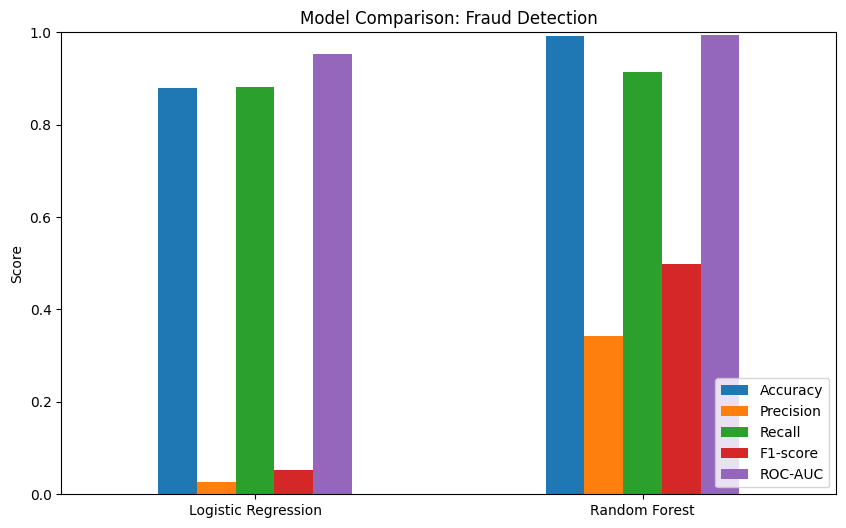

In [21]:
# ============================================================
# STEP 14: MODEL COMPARISON GRAPH
# ============================================================

results_df = pd.DataFrame(results).T

print(results_df)

results_df.plot(kind="bar", figsize=(10, 6))

plt.title("Model Comparison: Fraud Detection")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

In [22]:
# ============================================================
# STEP 15: FAST HYPERPARAMETER TUNING - RANDOM FOREST
# ============================================================

rf_pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

params = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [8, 12],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=params,
    scoring="f1",
    cv=2,
    n_iter=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

search.fit(X_train, y_train)

best_fraud_model = search.best_estimator_

print("Best parameters:", search.best_params_)


Fitting 2 folds for each of 3 candidates, totalling 6 fits
Best parameters: {'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_depth': 8}


In [25]:
# ============================================================
# STEP 15: XGBOOST HYPERPARAMETER TUNING
# ============================================================

!pip install xgboost -q

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# Calculate imbalance ratio
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight
    ))
])

params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

search = RandomizedSearchCV(
    xgb_pipe,
    param_distributions=params,
    scoring="f1",
    cv=3,
    n_iter=5,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

search.fit(X_train, y_train)

best_xgb_model = search.best_estimator_

print("Best parameters:", search.best_params_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best parameters: {'model__subsample': 1.0, 'model__n_estimators': 200, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__colsample_bytree': 1.0}


Final Accuracy: 0.9727542157097382
Final Precision: 0.11609358383551932
Final Recall: 0.916083916083916
Final F1-score: 0.2060720465628441
Final ROC-AUC: 0.9892591778874371
              precision    recall  f1-score   support

           0       1.00      0.97      0.99    553574
           1       0.12      0.92      0.21      2145

    accuracy                           0.97    555719
   macro avg       0.56      0.94      0.60    555719
weighted avg       1.00      0.97      0.98    555719



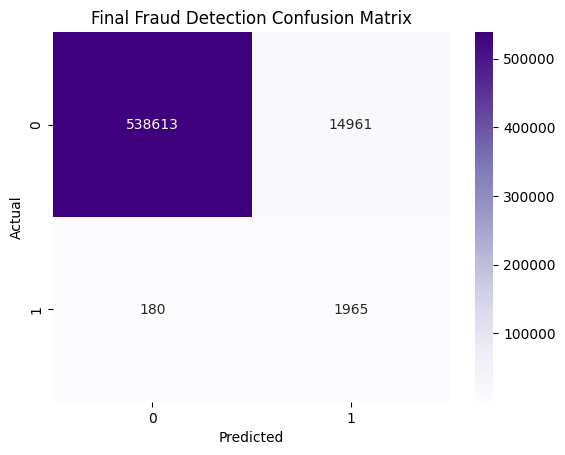

In [26]:
# ============================================================
# STEP 16: FINAL EVALUATION
# ============================================================

y_pred_final = best_fraud_model.predict(X_test)

y_prob_final = best_fraud_model.predict_proba(X_test)[:, 1]

print("Final Accuracy:", accuracy_score(y_test, y_pred_final))
print("Final Precision:", precision_score(y_test, y_pred_final))
print("Final Recall:", recall_score(y_test, y_pred_final))
print("Final F1-score:", f1_score(y_test, y_pred_final))
print("Final ROC-AUC:", roc_auc_score(y_test, y_prob_final))

print(classification_report(y_test, y_pred_final))

cm = confusion_matrix(y_test, y_pred_final)

sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
plt.title("Final Fraud Detection Confusion Matrix after hyperparameter tuning.")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

XGBoost Accuracy: 0.983223535635816
XGBoost Precision: 0.18339802399435426
XGBoost Recall: 0.9692307692307692
XGBoost F1-score: 0.30843409242637787
XGBoost ROC-AUC: 0.9977968243705073
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    553574
           1       0.18      0.97      0.31      2145

    accuracy                           0.98    555719
   macro avg       0.59      0.98      0.65    555719
weighted avg       1.00      0.98      0.99    555719



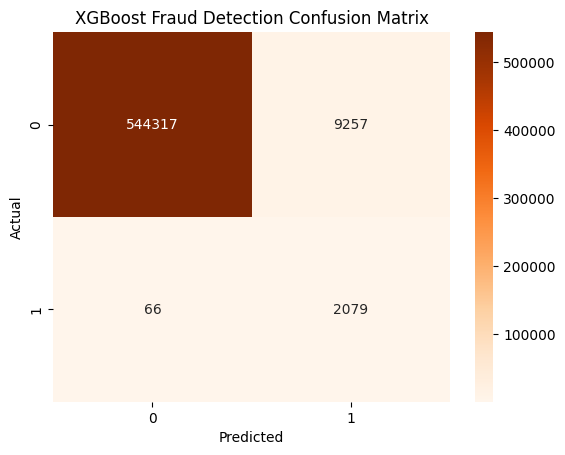

In [27]:
# ============================================================
# STEP 16: XGBOOST FINAL EVALUATION
# ============================================================

y_pred_xgb = best_xgb_model.predict(X_test)

y_prob_xgb = best_xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost Precision:", precision_score(y_test, y_pred_xgb))
print("XGBoost Recall:", recall_score(y_test, y_pred_xgb))
print("XGBoost F1-score:", f1_score(y_test, y_pred_xgb))
print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

print(classification_report(y_test, y_pred_xgb))

cm = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
plt.title("XGBoost Fraud Detection Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

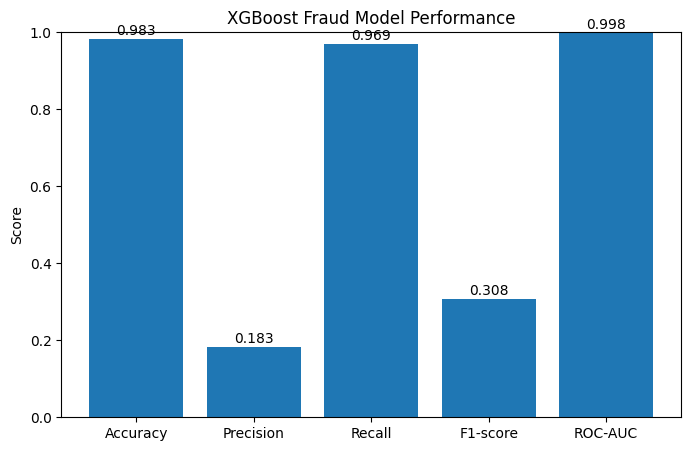

In [28]:
# ============================================================
# STEP 17: XGBOOST METRICS GRAPH
# ============================================================

xgb_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb),
    "Recall": recall_score(y_test, y_pred_xgb),
    "F1-score": f1_score(y_test, y_pred_xgb),
    "ROC-AUC": roc_auc_score(y_test, y_prob_xgb)
}

plt.figure(figsize=(8, 5))
plt.bar(xgb_metrics.keys(), xgb_metrics.values())

plt.title("XGBoost Fraud Model Performance")
plt.ylabel("Score")
plt.ylim(0, 1)

for i, v in enumerate(xgb_metrics.values()):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")

plt.show()

           Random Forest   XGBoost
Accuracy        0.972754  0.983224
Precision       0.116094  0.183398
Recall          0.916084  0.969231
F1-score        0.206072  0.308434
ROC-AUC         0.989259  0.997797


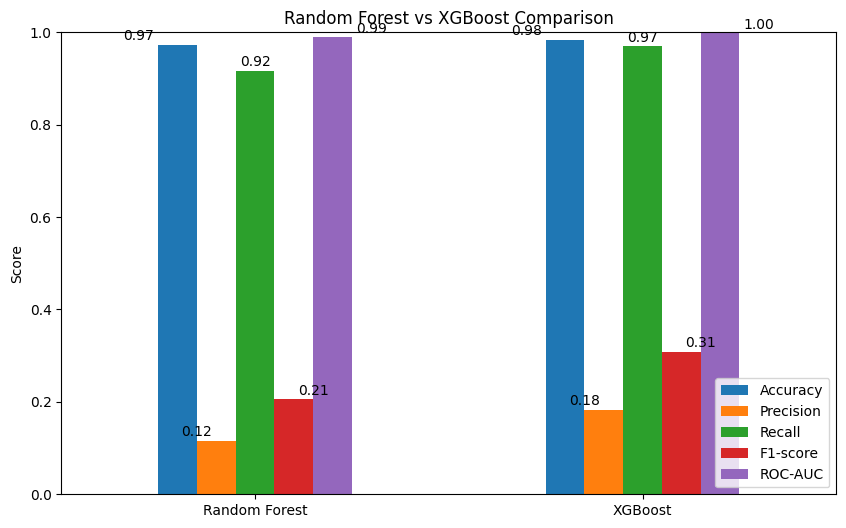

In [29]:
# ============================================================
# MODEL COMPARISON: RANDOM FOREST vs XGBOOST
# ============================================================

# Random Forest predictions (already trained)
y_pred_rf = best_fraud_model.predict(X_test)
y_prob_rf = best_fraud_model.predict_proba(X_test)[:, 1]

# XGBoost predictions
y_pred_xgb = best_xgb_model.predict(X_test)
y_prob_xgb = best_xgb_model.predict_proba(X_test)[:, 1]

# Metrics dictionary
rf_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1-score": f1_score(y_test, y_pred_rf),
    "ROC-AUC": roc_auc_score(y_test, y_prob_rf)
}

xgb_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb),
    "Recall": recall_score(y_test, y_pred_xgb),
    "F1-score": f1_score(y_test, y_pred_xgb),
    "ROC-AUC": roc_auc_score(y_test, y_prob_xgb)
}

# Convert to DataFrame
comparison_df = pd.DataFrame({
    "Random Forest": rf_metrics,
    "XGBoost": xgb_metrics
})

print(comparison_df)

# Plot comparison
comparison_df.T.plot(kind="bar", figsize=(10,6))

plt.title("Random Forest vs XGBoost Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")

for i in range(len(comparison_df.columns)):
    for j in range(len(comparison_df.index)):
        value = comparison_df.iloc[j, i]
        plt.text(i + (j-2)*0.15, value + 0.01, f"{value:.2f}", ha='center')

plt.show()

In [30]:
# ============================================================
# STEP 18: SAVE FINAL MODEL
# ============================================================

joblib.dump(best_fraud_model, "fraud_detection_model.pkl")

print("Fraud detection model saved successfully!")

Fraud detection model saved successfully!
